In [1]:
import pandas as pd
import seaborn as sns
import sklearn
print("พร้อมแล้ว!", pd.__version__, sklearn.__version__)

พร้อมแล้ว! 3.0.6 1.9.1


In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [5]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [7]:
df["Survived"].mean()

np.float64(0.3838383838383838)

In [8]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

<Axes: xlabel='Sex', ylabel='Survived'>

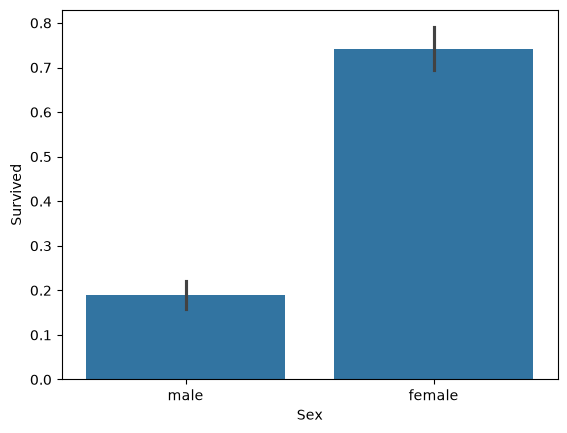

In [10]:
sns.barplot(data=df, x="Sex", y="Survived")

In [11]:
df.groupby("Pclass")["Survived"].mean()


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

<Axes: xlabel='Pclass', ylabel='Survived'>

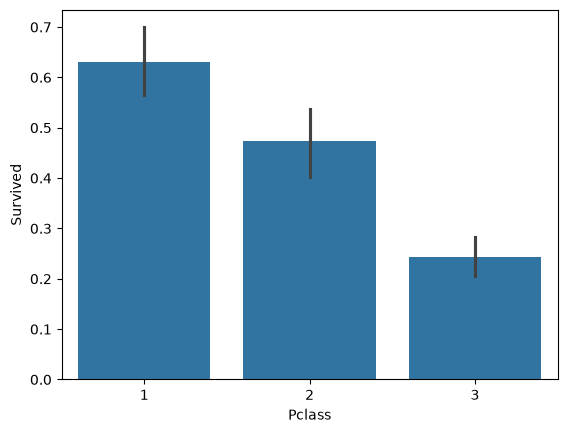

In [12]:
sns.barplot(data=df, x="Pclass", y="Survived")

In [13]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [14]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [15]:
pd.crosstab(df["Sex"], df["Survived"], normalize="index")

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


<Axes: xlabel='Pclass', ylabel='Survived'>

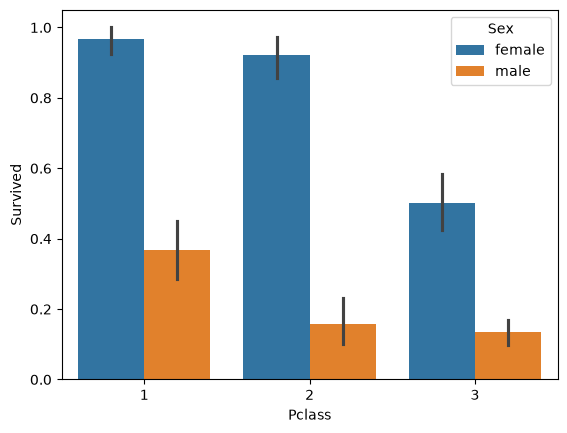

In [16]:
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")

In [76]:
df[df["Pclass"] == 1]["Survived"].mean()

np.float64(0.6296296296296297)

In [82]:
df[(df["Pclass"] == 1) & (df["Sex"] == "female")]["Survived"].mean()

np.float64(0.9680851063829787)

In [81]:
df[(df["Pclass"] == 1) & (df["Sex"] == "male")]["Survived"].mean()

np.float64(0.36885245901639346)

In [77]:
df[df["Pclass"] == 2]["Survived"].mean()

np.float64(0.47282608695652173)

In [78]:
df[df["Pclass"] == 3]["Survived"].mean()

np.float64(0.24236252545824846)

<Axes: xlabel='Age', ylabel='Count'>

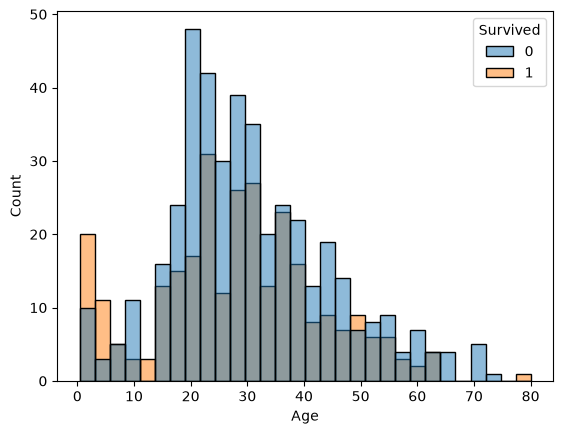

In [17]:
sns.histplot(data=df, x="Age", hue="Survived", bins=30)

In [18]:
kids=df[df["Age"] < 13 ]
kids.value_counts()

PassengerId  Survived  Pclass  Name                                 Sex     Age    SibSp  Parch  Ticket   Fare      Cabin    Embarked
11           1         3       Sandstrom, Miss. Marguerite Rut      female  4.00   1      1      PP 9549  16.7000   G6       S           1
184          1         2       Becker, Master. Richard F            male    1.00   2      1      230136   39.0000   F4       S           1
194          1         2       Navratil, Master. Michel M           male    3.00   1      1      230080   26.0000   F2       S           1
206          0         3       Strom, Miss. Telma Matilda           female  2.00   0      1      347054   10.4625   G6       S           1
298          0         1       Allison, Miss. Helen Loraine         female  2.00   1      2      113781   151.5500  C22 C26  S           1
306          1         1       Allison, Master. Hudson Trevor       male    0.92   1      2      113781   151.5500  C22 C26  S           1
341          1         2       N

In [19]:
kids["Survived"].mean()

np.float64(0.5797101449275363)

In [20]:
adult=df[df["Age"] >= 13]
adult["Survived"].mean()

np.float64(0.3875968992248062)

In [21]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 100], labels=["kids", "adult"])
df[["Age", "AgeGroup"]].head(10)

,Age,AgeGroup
0,22.0,adult
1,38.0,adult
2,26.0,adult
3,35.0,adult
4,35.0,adult
5,NaN,NaN
6,54.0,adult
7,2.0,kids
8,27.0,adult
9,14.0,adult


<Axes: xlabel='AgeGroup', ylabel='Survived'>

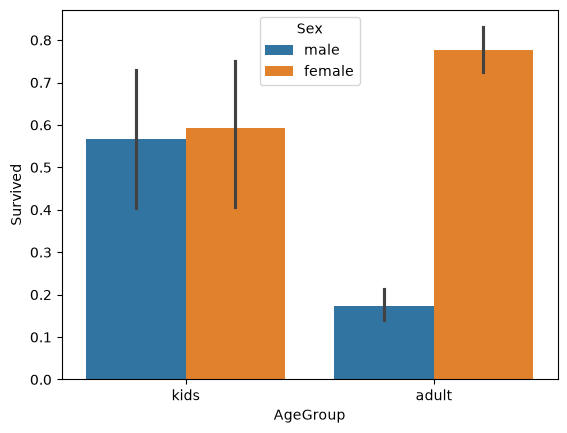

In [22]:
sns.barplot(data=df, x="AgeGroup", y="Survived", hue="Sex")

<Axes: xlabel='AgeGroup', ylabel='Survived'>

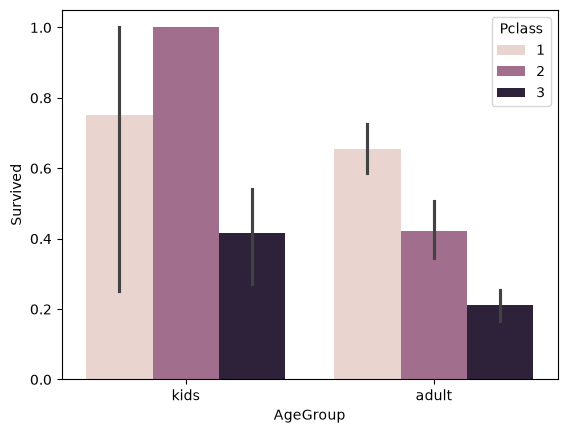

In [23]:
sns.barplot(data=df, x="AgeGroup", y="Survived", hue="Pclass")

<Axes: xlabel='Fare', ylabel='Count'>

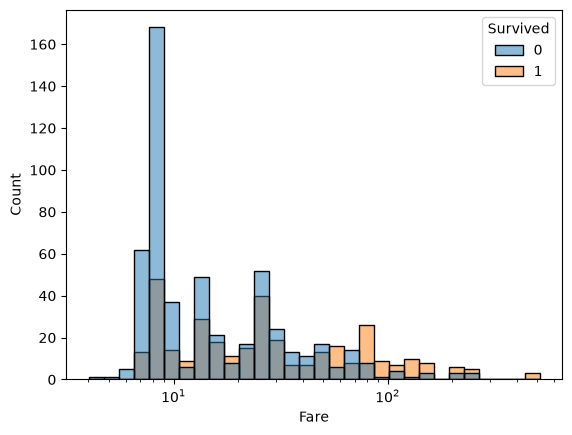

In [24]:
sns.histplot(data=df, x="Fare", hue="Survived", bins=30, log_scale=True)

In [25]:
expensive = df[df["Fare"] > 70]
expensive["Survived"].mean()

np.float64(0.7238095238095238)

In [26]:
pool = df[df["Fare"] <= 70]
pool["Survived"].mean()

np.float64(0.3384223918575064)

In [27]:
len(expensive), len(pool)

(105, 786)

<Axes: xlabel='FamilySize', ylabel='Survived'>

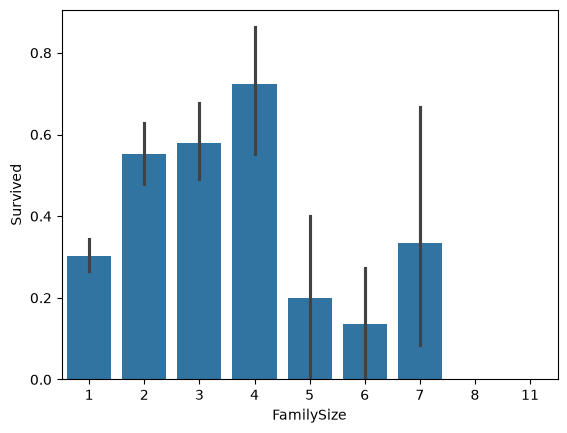

In [28]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
sns.barplot(data=df, x="FamilySize", y="Survived")

In [29]:
df[df["FamilySize"] > 1]["Survived"].mean()

np.float64(0.5056497175141242)

In [30]:
df[df["FamilySize"] <= 1]["Survived"].mean()

np.float64(0.30353817504655495)

In [31]:
alone = df[df["FamilySize"] == 1]
alone["Sex"].value_counts(normalize=True)

Sex
male      0.765363
female    0.234637
Name: proportion, dtype: float64

In [63]:
df[df["FamilySize"] <= 1]["Pclass"].value_counts()

Pclass
3    324
1    109
2    104
Name: count, dtype: int64

In [64]:
df[df["FamilySize"] > 1]["Pclass"].value_counts()

Pclass
3    167
1    107
2     80
Name: count, dtype: int64

In [66]:
df[df["Ticket"] == "347082"][["Name", "Sex", "Age", "Survived"]]
df["IsMale"]     = (df["Sex"] == "male").astype(int)                  # ผู้ชาย = 1, ผู้หญิง = 0
df["FamMales"]   = df.groupby("Ticket")["IsMale"].transform("sum")    # เอา 1 + 1 + 0 ก็คือหาผู้ชายนั่นแหละ
df["FamCount"]   = df.groupby("Ticket")["IsMale"].transform("count")  # นับจำนวนคนตามจำนวนช่องว่าง
df["FamFemales"] = df["FamCount"] - df["FamMales"]                    # จำนวนผู้หญิง = ทั้งหมด − ผู้ชาย

In [69]:
df[(df["FamCount"] > 1) & (df["FamMales"] > df["FamFemales"])]["Survived"].mean()

np.float64(0.3010752688172043)

In [70]:
df[(df["FamCount"] > 1) & (df["FamMales"] < df["FamFemales"])]["Survived"].mean()

np.float64(0.6528925619834711)

In [79]:
df[df["FamilySize"] == 4]["FamMales"].value_counts()

FamMales
1    17
2     6
0     6
Name: count, dtype: int64

In [80]:
df[df["FamilySize"] == 4]["FamFemales"].value_counts()

FamFemales
2    12
1     7
4     4
0     3
3     3
Name: count, dtype: int64

In [71]:
df["Ticket"] == "347082"

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Ticket, Length: 891, dtype: bool

In [72]:
df[df["Ticket"] == "347082"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,FamilySize,IsMale,FamMales,FamCount,FamFemales
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.275,NaN,S,adult,7,1,2,7,5
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.275,NaN,S,kids,7,0,2,7,5
541,542,0,3,"Andersson, Miss. Ingeborg Constanzia",female,9.0,4,2,347082,31.275,NaN,S,kids,7,0,2,7,5
542,543,0,3,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.275,NaN,S,kids,7,0,2,7,5
610,611,0,3,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,1,5,347082,31.275,NaN,S,adult,7,0,2,7,5
813,814,0,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.275,NaN,S,kids,7,0,2,7,5
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.275,NaN,S,kids,7,1,2,7,5


In [73]:
df[df["Ticket"] == "347082"][["Name", "Sex", "Age", "Survived"]]

,Name,Sex,Age,Survived
13,"Andersson, Mr. Anders Johan",male,39.0,0
119,"Andersson, Miss. Ellis Anna Maria",female,2.0,0
541,"Andersson, Miss. Ingeborg Constanzia",female,9.0,0
542,"Andersson, Miss. Sigrid Elisabeth",female,11.0,0
610,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,0
813,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,0
850,"Andersson, Master. Sigvard Harald Elias",male,4.0,0


In [33]:
//สถานที่ขึ้น ท่าเรือ S

SyntaxError: invalid syntax (3414756941.py, line 1)

In [34]:
embarked_s = df[df["Embarked"] == "S"]
embarked_s["Survived"].mean()

np.float64(0.33695652173913043)

In [60]:
len(embarked_s)

644

In [35]:
df[df["Embarked"] == "S"]["Sex"].value_counts()

Sex
male      441
female    203
Name: count, dtype: int64

In [ ]:
df[df["Embarked"] == "S"]["Pclass"].value_counts()

In [51]:
df[(df["Embarked"] == "S") & (df["Pclass"] == 1)]["Survived"].mean()

np.float64(0.5826771653543307)

In [52]:
df[(df["Embarked"] == "S") & (df["Pclass"] == 2)]["Survived"].mean()

np.float64(0.4634146341463415)

In [53]:
df[(df["Embarked"] == "S") & (df["Pclass"] == 3)]["Survived"].mean()

np.float64(0.18980169971671387)

In [36]:
สถานที่ขึ้น ท่าเรือ C

SyntaxError: invalid syntax (727348897.py, line 1)

In [ ]:
embarked_c = df[df["Embarked"] == "C"]
embarked_c["Survived"].mean()

In [ ]:
len(embarked_c)

In [37]:
df[df["Embarked"] == "C"]["Sex"].value_counts()

Sex
male      95
female    73
Name: count, dtype: int64

In [38]:
df[df["Embarked"] == "C"]["Pclass"].value_counts()

Pclass
1    85
3    66
2    17
Name: count, dtype: int64

In [47]:
df[(df["Embarked"] == "C") & (df["Pclass"] == 1)]["Survived"].mean()

np.float64(0.6941176470588235)

In [48]:
df[(df["Embarked"] == "C") & (df["Pclass"] == 2)]["Survived"].mean()

np.float64(0.5294117647058824)

In [50]:
df[(df["Embarked"] == "C") & (df["Pclass"] == 3)]["Survived"].mean()

np.float64(0.3787878787878788)

In [ ]:
สถานที่ขึ้น ท่าเรือ Q

In [ ]:
embarked_q = df[df["Embarked"] == "Q"]
embarked_q["Survived"].mean()

In [57]:
df[df["Embarked"] == "Q"]["Sex"].value_counts()

Sex
male      41
female    36
Name: count, dtype: int64

In [58]:
df[df["Embarked"] == "Q"]["Pclass"].value_counts()

Pclass
3    72
2     3
1     2
Name: count, dtype: int64

In [54]:
df[(df["Embarked"] == "Q") & (df["Pclass"] == 1)]["Survived"].mean()

np.float64(0.5)

In [55]:
df[(df["Embarked"] == "Q") & (df["Pclass"] == 2)]["Survived"].mean()

np.float64(0.6666666666666666)

In [56]:
df[(df["Embarked"] == "Q") & (df["Pclass"] == 3)]["Survived"].mean()

np.float64(0.375)

<Axes: xlabel='Embarked', ylabel='count'>

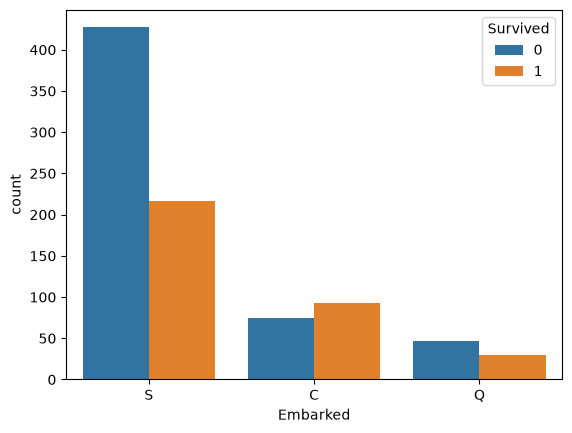

In [62]:
sns.countplot(data=df, x="Embarked", hue="Survived")